# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.stats import ttest_ind, norm
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import RCTs, DataGenerationProcess
import core.rct as rct
from core.variables import *

# DGP

In [6]:
dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

dgp = RCTs(**dgp_params)

In [7]:
treated_sample, control_sample = dgp.sample(sample_size=5000, seed=0)

# Estimation

In [10]:
emp_te_arr, emp_var_arr = rct.estimate_treatment_effects([treated_sample, control_sample])

# Selection

In [12]:
selection = rct.select_higher_effect(treatment_effects=emp_te_arr, treatment_vars=emp_var_arr)

# Evaluation

In [13]:
val_est = rct.obj_func(selection=selection, treatment_effects=emp_te_arr)
val_true = rct.obj_func(selection=selection, treatment_effects=dgp.treatment_effects)

result_df = pd.DataFrame({
    'Rank and Select': [val_est, val_true, val_est - val_true]
}, index=['Estimated Policy Value', 'True Policy Value', 'Winner\'s Curse'])
result_df

,Rank and Select
Estimated Policy Value,1.127324
True Policy Value,1.125405
Winner's Curse,0.001918


In [14]:
del dgp, treated_sample, control_sample, emp_te_arr, selection, val_est, val_true, result_df

# Winner's Curse

In [15]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 1000}

estimators_dict = {}

result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    2.3s finished


In [16]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.1104 (0.0004)
  - Average Estimated Value: 1.1459 (0.0009)
  - Average Winner's Curse (%): 35.52% (0.90%)


# Estimating Winner's Curse

In [34]:
dgp = RCTs(**dgp_params)
samples = dgp.sample(sample_size=data_params['sample_size'], seed=0)

## Standard Bootstrap

In [19]:
boot_wc_dstn_dict = rct.get_wc_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


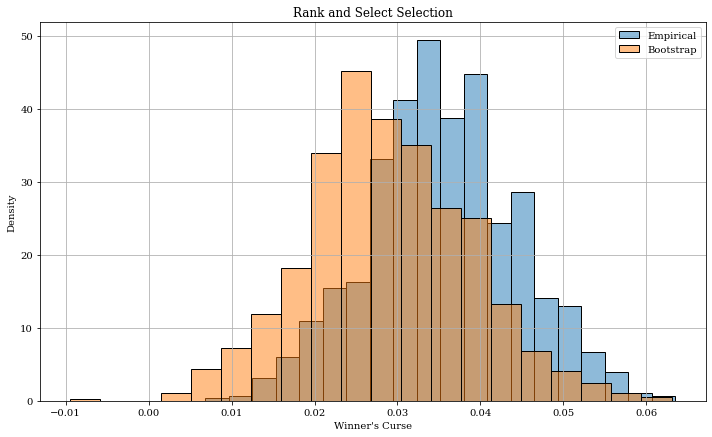

In [20]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [21]:
boot_wc_dstn_dict = rct.get_wc_m_out_of_n_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=0.95, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.2s finished


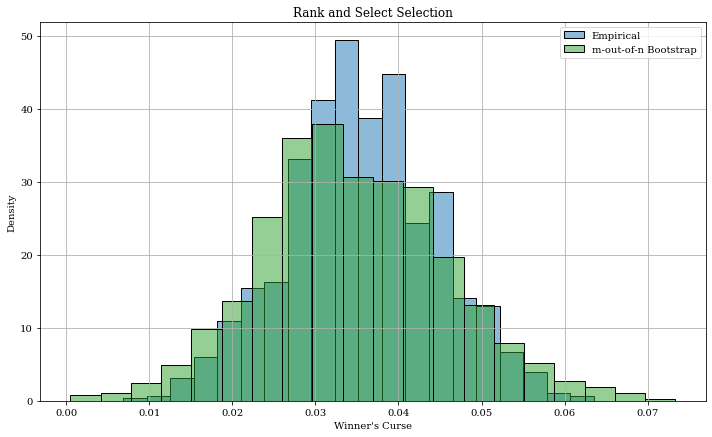

In [22]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [23]:
boot_wc_dstn_dict = rct.get_wc_num_boot_dstn(
    samples, 
    optimization_params=optimization_params, 
    n_bootstraps=1000, power=-0.45, 
    n_jobs=-1, verbose=True, seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:    0.1s finished


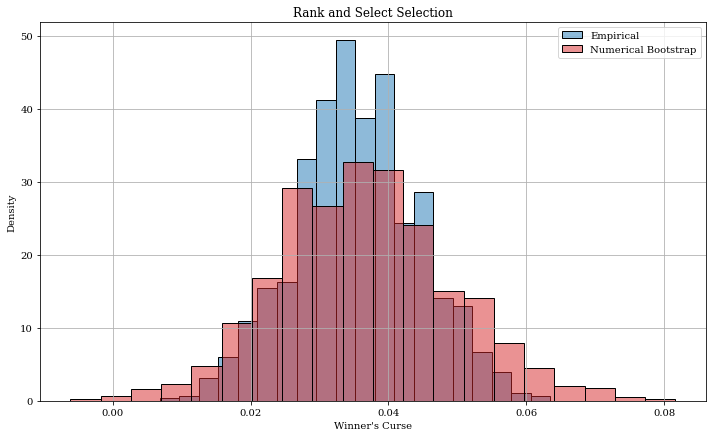

In [24]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='Numerical Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'{display_name} Selection')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

In [25]:
del dgp, samples, boot_wc_dstn_dict

# Bias Correction

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [8]:
result_records = rct.repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict,
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = rct.calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   54.6s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:  5.3min
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed: 12.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 14.5min finished



Selection with Rank and Select:
  - True Value: 1.1103 (0.0004)
Winner's Curse: 
  - No Correction: 35.54% (0.88%)
  - Standard Bootstrap: 5.82% (0.96%)
  - m-out-of-n Bootstrap: -0.74% (0.97%)
  - Numerical Bootstrap: -1.88% (0.98%)
  - Bayes (Normal): 24.31% (0.87%)
  - EB (Spike-and-Slab): 13.15% (0.87%)
  - Adj. EB (Spike-and-Slab): -7.85% (2.29%)
Sample Splitting: 
  - True Value: 1.1020 (0.0005)
  - Estimated Value: 1.1017 (0.0015)
  - Winner's Curse (%): -0.30% (1.41%)


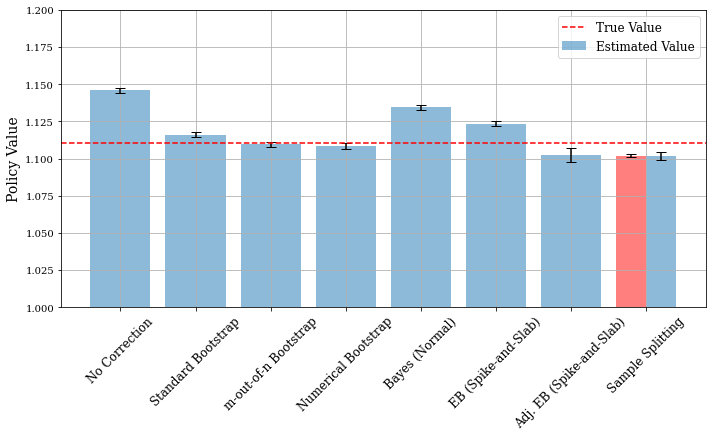

In [9]:
delta_tau = dgp_params['base_effects'][1].mean - dgp_params['base_effects'][0].mean

optimizer_key = 'rank_and_select'

wc_dict = {}
val_est_dict = {}

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

for estimator_key in ['nc'] + list(estimators_dict.keys()):
    if estimator_key == 'sample_splitting':
        continue
    
    estimator_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    wc_dict.update({
        estimator_name: {
            "Avg. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_avg'],
            "S.E. Winners Curse": wc_measures_dict[f'{optimizer_key}_{estimator_key}_wc_se'],
        }
    })
    val_est_dict.update({
        estimator_name: {
            "Avg. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_avg'],
            "S.E. Estimated Value": wc_measures_dict[f'{optimizer_key}_{estimator_key}_val_est_se'],
        }
    })

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
print(f"Winner's Curse: ")
for estimator_name in wc_dict.keys():
    print(f'  - {estimator_name}: {wc_dict[estimator_name]["Avg. Winners Curse"]/delta_tau:.2%} ({wc_dict[estimator_name]["S.E. Winners Curse"]/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'Sample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(val_est_dict))
bar_values = [val_est_dict[estimator_name]["Avg. Estimated Value"] for estimator_name in val_est_dict.keys()]
bar_errors = [1.95 * val_est_dict[estimator_name]["S.E. Estimated Value"] for estimator_name in val_est_dict.keys()]
    

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
ax.set_xticks(
    np.arange(len(val_est_dict) + 1), 
    labels=list(val_est_dict.keys()) + ['Sample Splitting'], 
    rotation=45, 
    fontsize=tick_label_size
)
ax.set_ylim([1.0, 1.2])
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Comparative Statics

## Number of Arms

In [10]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': np.nan, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [35]:
n_arms_list = [10, 25, 50, 75, 100]

num_arms_result_dict = {n_arms: None for n_arms in n_arms_list}

for n_arms in n_arms_list:
    print(f'\nNumber of Experiments = {n_arms}')
    dgp_params['n_experiments'] = n_arms

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    num_arms_result_dict[n_arms] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Experiments = 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   29.2s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  1.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  1.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 25
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   54.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  3.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  5.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  6.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 75
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  7.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:  9.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Experiments = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  9.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.4min finished


In [46]:
num_arms_wc_avg_df = pd.DataFrame({
    n_arms: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for n_arms, wc_dict in num_arms_result_dict.items()
}).T / dgp_params['prior_mean'] * 100

num_arms_wc_se_df = pd.DataFrame({
    n_arms: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for n_arms, wc_dict in num_arms_result_dict.items()
}).T / dgp_params['prior_mean'] * 100

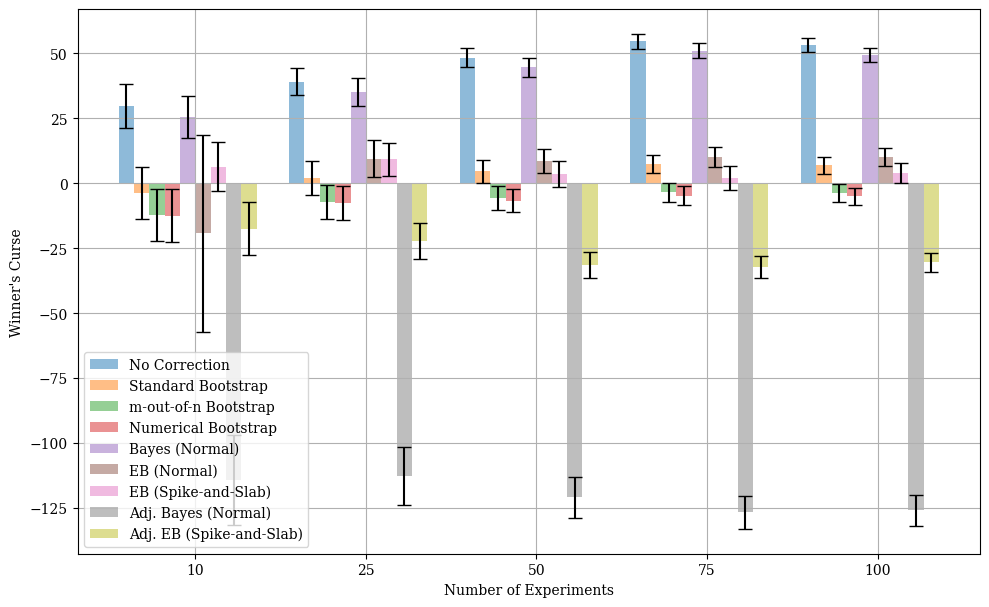

In [53]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'threshold'

n_estimators = len(estimators_dict.keys()) + 1
bar_positions = np.arange(len(num_arms_wc_avg_df.index))
bar_width = 0.09 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + list(estimators_dict.keys())):
    bar_values = num_arms_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * num_arms_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Number of Experiments')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(num_arms_wc_avg_df.index)), 
    labels=num_arms_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

## Delta Tau

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': None,
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': 100}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [ ]:
base_tau = 1.0
delta_tau_list = [0.01, 0.05, 0.1, 0.5]

delta_tau_result_dict = {delta_tau: None for delta_tau in delta_tau_list}

for delta_tau in delta_tau_list:
    print(f'\nDelta tau= {delta_tau}')
    
    dgp_params['base_effects'] = [UnivariateGaussian(base_tau, std=0.1), UnivariateGaussian(base_tau + delta_tau, std=0.1)]

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    delta_tau_result_dict[delta_tau] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )

In [ ]:
delta_tau_wc_avg_df = pd.DataFrame({
delta_tau: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg'] / delta_tau
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for delta_tau, wc_dict in delta_tau_result_dict.items()
}).T * 100

delta_tau_wc_se_df = pd.DataFrame({
    delta_tau: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se'] / delta_tau
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for delta_tau, wc_dict in delta_tau_result_dict.items()
}).T * 100

In [ ]:
delta_tau_wc_avg_df

,nc_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_normal_wc_avg,eb_spike_slab_wc_avg,bayes_normal_adj_wc_avg,eb_spike_slab_adj_wc_avg
0.01,17.153132,3.907317,1.147778,0.472458,16.585675,2.214512,-3.237479,-28.443862,-8.289235
0.05,14.126925,2.746032,0.270298,-0.207625,13.495418,2.176216,-2.087774,-27.071572,-8.022390
0.10,10.614051,1.378565,-0.763324,-1.018471,9.892154,1.996587,0.774811,-25.178851,-6.093211
0.50,0.215560,-0.338511,-0.651870,-0.483709,-1.754428,-0.509700,0.151375,-4.489260,-0.129287


In [ ]:
delta_tau_wc_se_df

,nc_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_normal_wc_se,eb_spike_slab_wc_se,bayes_normal_adj_wc_se,eb_spike_slab_adj_wc_se
0.01,0.274656,0.350360,0.359477,0.373862,0.270041,0.428597,0.440126,0.672680,0.340849
0.05,0.277433,0.343419,0.352772,0.364531,0.272619,0.394790,0.462517,0.661024,0.387056
0.10,0.275311,0.331579,0.340306,0.348840,0.270348,0.358296,0.403312,0.613416,0.385013
0.50,0.282376,0.290596,0.294268,0.294569,0.276880,0.306211,0.284799,0.320384,0.289403


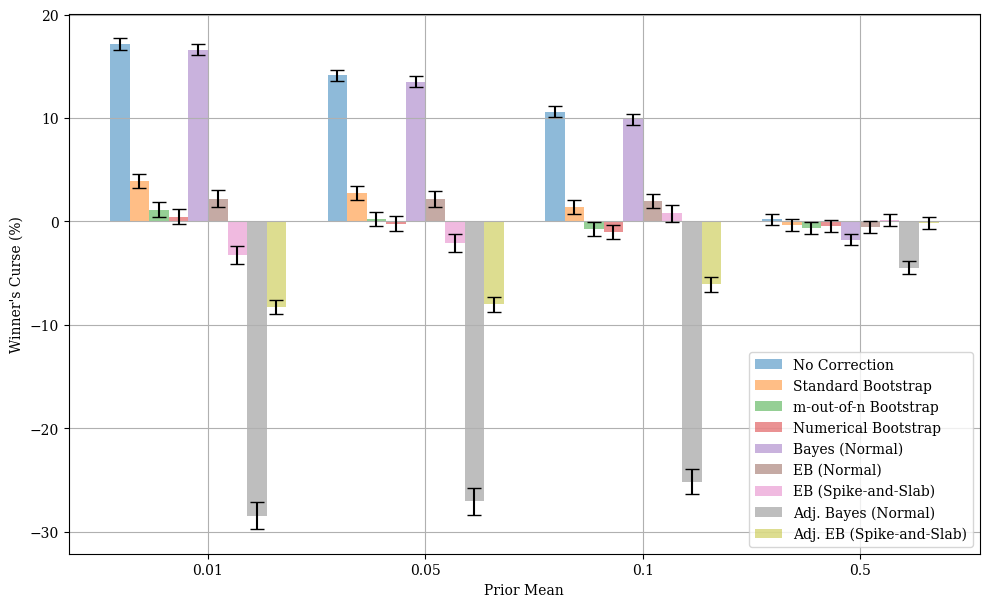

In [ ]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'threshold'

n_estimators = len(estimators_dict.keys()) + 1
bar_positions = np.arange(len(delta_tau_wc_avg_df.index))
bar_width = 0.09 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + list(estimators_dict.keys())):
    bar_values = delta_tau_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * delta_tau_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Prior Mean')
ax.set_ylabel('Winner\'s Curse (%)')
ax.set_xticks(
    np.arange(len(delta_tau_wc_avg_df.index)), 
    labels=delta_tau_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

## Sample Size

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': rct.select_higher_effect,
        'params': {}, 
        'display_name': 'Rank and Select'
    }, 
}

dgp_params = {
    'n_experiments': 100, 
    'base_effects': [UnivariateGaussian(1, std=0.1), UnivariateGaussian(1.1, std=0.1)],
    'noise_vars': [UnivariateGaussian(0, std=1), UnivariateGaussian(0, std=1)],
    'dgp_seed': 0
}

data_params = {'sample_size': np.nan}

experiment_params = {'n_repeats': 500}

estimators_dict = {
    'sample_splitting': {
        'estimator': rct.sample_splitting_estimate,
        'params': {'estimation_split': 0.5},
        'display_name': 'Sample Splitting'
    }, 
    'standard_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'bootstrap_method': 'standard', 'n_jobs': 1}, 
        'display_name': 'Standard Bootstrap', 
    }, 
    'm_out_of_n_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': 0.95, 'bootstrap_method': 'm_out_of_n', 'n_jobs': 1}, 
        'display_name': 'm-out-of-n Bootstrap', 
    },
    'numerical_bootstrap': {
        'estimator': rct.bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 500, 'power': -0.45, 'bootstrap_method': 'numerical', 'n_jobs': 1}, 
        'display_name': 'Numerical Bootstrap', 
    }, 
    'bayes_normal': {
        'estimator': rct.bayes_estimate, 
        'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
        'display_name': 'Bayes (Normal)'
    }, 
    'eb_spike_slab': {
        'estimator': rct.empirical_bayes_estimate, 
        'params': {'prior': 'spike_slab', 'pi': 0.5},
        'display_name': 'EB (Spike-and-Slab)'
    }, 
    'eb_spike_slab_adj': {
        'estimator': rct.empirical_bayes_selection_adjusted_estimate,
        'params': {
            'pi': 0.5, 'max_iter': 100, 'tol': 1e-6, 'n_jobs': -1
        },
        'display_name': 'Adj. EB (Spike-and-Slab)'
    }
}

In [18]:
sample_size_list = [50, 100, 500, 1000]

sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size = {sample_size}')
    data_params['sample_size'] = sample_size

    result_records = rct.repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict,
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = rct.calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size = 50
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  9.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.0min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:  9.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 10.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.5min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size = 1000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  3.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 10.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 12.8min finished


In [19]:
sample_size_wc_avg_df = pd.DataFrame({
    sample_size: {
        f'{estimator_key}_wc_avg': wc_dict[f'{optimizer_key}_{estimator_key}_wc_avg']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for sample_size, wc_dict in sample_size_result_dict.items()
}).T / dgp_params['prior_mean'] * 100

sample_size_wc_se_df = pd.DataFrame({
    sample_size: {
        f'{estimator_key}_wc_se': wc_dict[f'{optimizer_key}_{estimator_key}_wc_se']
        for optimizer_key in optimization_params.keys() 
        for estimator_key in ['nc'] + list(estimators_dict.keys())
    } for sample_size, wc_dict in sample_size_result_dict.items()
}).T / dgp_params['prior_mean'] * 100

In [20]:
sample_size_wc_avg_df

,nc_wc_avg,standard_bootstrap_wc_avg,m_out_of_n_bootstrap_wc_avg,numerical_bootstrap_wc_avg,bayes_normal_wc_avg,eb_normal_wc_avg,eb_spike_slab_wc_avg,bayes_normal_adj_wc_avg,eb_spike_slab_adj_wc_avg
50,94.112794,17.615719,3.650251,1.082829,85.679436,13.630499,-2.166226,-181.321800,-42.310311
100,53.070256,6.892826,-3.816621,-5.092353,49.460771,9.982935,3.874057,-125.894256,-30.466054
500,10.974742,-0.155509,-4.205426,-4.221172,10.395082,3.412407,1.015896,-34.334708,-13.187892
1000,5.555598,-0.009241,-2.339373,-2.275723,5.275194,1.817599,0.238281,-16.500661,-8.337039


In [21]:
sample_size_wc_se_df

,nc_wc_se,standard_bootstrap_wc_se,m_out_of_n_bootstrap_wc_se,numerical_bootstrap_wc_se,bayes_normal_wc_se,eb_normal_wc_se,eb_spike_slab_wc_se,bayes_normal_adj_wc_se,eb_spike_slab_adj_wc_se
50,2.505946,3.102345,3.182161,3.243216,2.417502,3.502617,4.258651,5.680505,3.498866
100,1.376554,1.657893,1.701532,1.744200,1.351739,1.791481,2.016560,3.067082,1.925067
500,0.290241,0.319467,0.327305,0.329829,0.289240,0.315456,0.320466,0.491451,0.348041
1000,0.141835,0.151717,0.154623,0.155781,0.141586,0.147754,0.148680,0.229888,0.167418


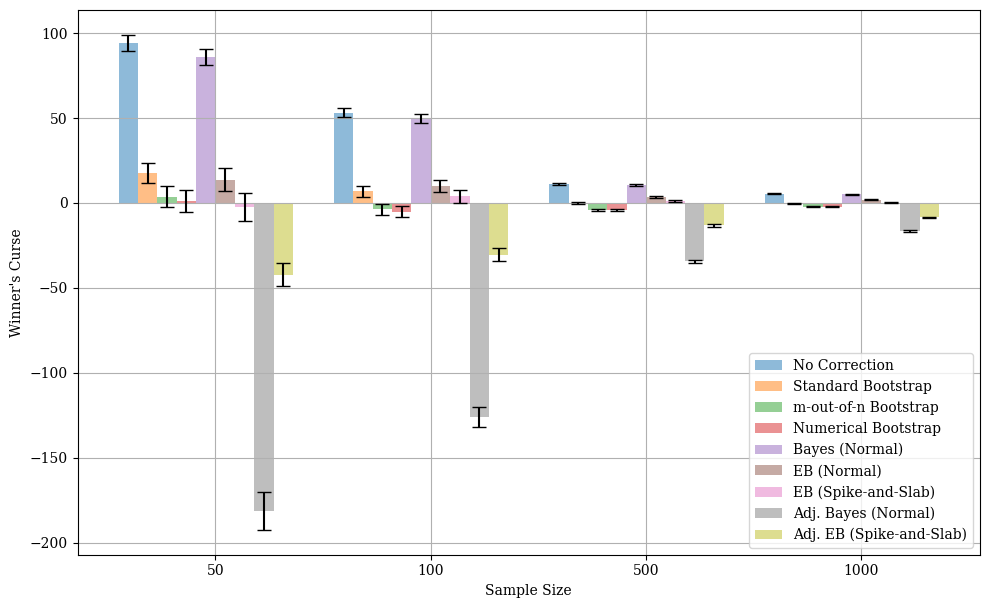

In [22]:
# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

optimizer_key = 'threshold'

n_estimators = len(estimators_dict.keys()) + 1
bar_positions = np.arange(len(sample_size_wc_avg_df.index))
bar_width = 0.09 * n_estimators

# plot the bars
for idx, estimator_key in enumerate(['nc'] + list(estimators_dict.keys())):
    bar_values = sample_size_wc_avg_df[f'{estimator_key}_wc_avg'].values
    bar_errors = 1.95 * sample_size_wc_se_df[f'{estimator_key}_wc_se'].values
    display_name = estimators_dict[estimator_key]['display_name'] if estimator_key != 'nc' else 'No Correction'

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=display_name, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel('Sample Size')
ax.set_ylabel('Winner\'s Curse')
ax.set_xticks(
    np.arange(len(sample_size_wc_avg_df.index)), 
    labels=sample_size_wc_avg_df.index, 
)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# Sketch